In [ ]:
#sshfs tbellagio@calc.carnegiescience.edu:/carnegie/nobackup/scratch/tbellagio/pang /Users/tatiana/Documents_new/pangenomes
# diskutil unmount force /Users/tatiana/Documents_new/pangenomes


sshfs -o reconnect,ServerAliveInterval=15,ServerAliveCountMax=3 \
tbellagio@calc.carnegiescience.edu:/carnegie/nobackup/scratch/tbellagio/pang \
/Users/tatiana/Documents_new/pangenomes



In [1]:
import pandas as pd

/tmp/ipykernel_999665/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
## the first step will be to check how mnay of the accessions we have for grenent are present in the already avilable/soon to be 1001 g projects and how many are not 

In [4]:
pang_69 = pd.read_csv('pang_69/accessions.csv', skiprows=2)

In [5]:
pang_23 = pd.read_csv('23_ara_pang/accessions.csv')

In [6]:
lr_1001= pd.read_csv('long_read_seq_ara/Athaliana_assembly_IDs_OVERVIEW.csv',dtype=str)

In [ ]:
grenenet = pd.read_csv('long_read_seq_ara/grene_ecotypes.csv')[['ID', 'name', 'country']]
grenenet = grenenet.dropna()
grenenet['acc_ID'] = grenenet['ID'].astype(int)

In [89]:
accessions = pd.read_csv('1001g_accesions_list.csv',header=None )

In [90]:
new_columns = [
    "acc_ID",
    "seq_by",
    "name",
    "country",
    "name_2",
    "lat",
    "lon",
    "collector",
    "date",
    "cs_number",
    "admixture_group",
    "unknown",
    "unknown2"
]

accessions.columns = new_columns

In [91]:
accessions.head()

,acc_ID,seq_by,name,country,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2
0,88,Monsanto,CYR,FRA,CYR,47.4000,0.683333,Valerie Le Corre,NaN,CS76790,western_europe,NaN,blu_circle
1,108,Monsanto,LDV-18,FRA,LDV,48.5167,-4.066670,Valerie Le Corre,NaN,CS77013,western_europe,NaN,blu_circle
2,139,Monsanto,LDV-46,FRA,LDV,48.5167,-4.066670,Valerie Le Corre,NaN,CS77014,western_europe,NaN,blu_circle
3,159,Monsanto,MAR2-3,FRA,Mar2,47.3500,3.933330,Valerie Le Corre,NaN,CS77070,western_europe,NaN,blu_circle
4,265,Monsanto,PYL-6,FRA,PYL,44.6500,-1.166670,Valerie Le Corre,NaN,CS77198,admixed,NaN,forbidden


In [92]:
## acc_ID 225 matches 
##  acc_ID + name 200 matches    ## tshisseem to be typos 
##  acc_ID + name + country 199 matches  ## ther eis one acession but i guess it is unsure if it estoniaor germany 
grenenet_accession = grenenet.merge(accessions, on = ['acc_ID'], how = 'left', suffixes=('_grene','_1001'))
grenenet_accession.drop(columns=['ID'],inplace=True)

In [93]:
grenenet_accession.to_csv('grenenet_accessions.csv',index=False)

In [94]:
## teh ones that were not found in the 1001g from greneet 
grenenet_accession[grenenet_accession['seq_by'].isna()]


,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2
35,Mt-0,LIB,6939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,Toufl-1,MAR,9940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,Vezzano2-1,ITA,9977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,Dog-4,TUR,9992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229,Ziv-24208,ISR,100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
230,Her-,ISR,100002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
## delete the F1 (Col-0/Cvi-0)
lr_1001 = lr_1001[lr_1001['Accession_Name'] != 'F1 (Col-0/Cvi-0)']

In [172]:
lr_1001.drop(columns=['QC_pipeline', 'Final_assembly', 'TMP_comments' ],inplace=True)

In [173]:
lr_1001.rename(columns={'Accession_ID': 'acc_ID'}, inplace=True)
lr_1001['acc_ID'] = lr_1001['acc_ID'].astype(int)

In [175]:
# Convert Latitude/Longitude safely
lr_1001['Latitude'] = pd.to_numeric(lr_1001['Latitude'], errors='coerce')
lr_1001['Longitude'] = pd.to_numeric(lr_1001['Longitude'], errors='coerce')


In [176]:
def extract_float(x):
    if pd.isna(x):
        return np.nan
    # Try direct float
    try:
        return float(x)
    except:
        pass
    # Extract potential float inside a messy string (e.g date)
    import re
    match = re.search(r"-?\d+\.\d+", str(x))
    if match:
        return float(match.group())
    return np.nan

lr_1001['Latitude'] = lr_1001['Latitude'].apply(extract_float)
lr_1001['Longitude'] = lr_1001['Longitude'].apply(extract_float)


In [177]:
lr_1001

,Assembly_ID,Accession_Name,acc_ID,Accession_alias,Original_Assembly_ID,Version,CSnumber,Latitude,Longitude,Altitude,...,Assembler,Individual_or_pool,Latest_released_Year,Published,Publication_First_author,Publication_year,Publication_Journal,Publication_DOI,Publication_URL,Best_unique_assembly
0,100000,Col-0,6909,TAIR10,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,Pool,NaN,yes,NaN,NaN,NaN,NaN,NaN,0.0
1,100001,Col-0,6909,TAIR12 version 1,100001.0,1.0,NaN,NaN,NaN,NaN,...,NaN,Pool,2023.0,no,TAIR,NaN,unpublished,NaN,NaN,0.0
2,100002,Col-0,6909,TAIR12 version 2,100001.0,2.0,NaN,NaN,NaN,NaN,...,NaN,Pool,2023.0,no,TAIR,NaN,unpublished,NaN,NaN,1.0
3,100003,Ler-0,7213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,yes,Berlin,2015.0,NatBiotechnol,10.1038/nbt.3238,https://www.nature.com/articles/nbt.3238,NaN
5,100005,Ler-0,7213,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,Pool,2016.0,yes,Zapata,2016.0,PNAS,10.1073/pnas.1607532113,https://www.pnas.org/doi/full/10.1073/pnas.160...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,100425,UKSW06-240,4840,NaN,NaN,1.0,CS79000,50,-5,NaN,...,Flye_v2.9-b1768,NaN,2024.0,no,NaN,NaN,unpublished,NaN,NaN,NaN
426,100426,UKSE06-541,5279,NaN,NaN,1.0,CS79004,51,NaN,NaN,...,nextDenovo_v2.5.0,NaN,2024.0,no,NaN,NaN,unpublished,NaN,NaN,NaN
427,100427,Yeg-7,9133,NaN,NaN,1.0,CS78867,40,45,NaN,...,Flye_v2.9-b1768,NaN,2024.0,no,NaN,NaN,unpublished,NaN,NaN,NaN
428,100428,Yeg-8,9134,NaN,NaN,1.0,CS78868,40,45,NaN,...,Flye_v2.9-b1768,NaN,2024.0,no,NaN,NaN,unpublished,NaN,NaN,NaN


In [99]:
print(len(grenenet_accession.merge(lr_1001, on = 'acc_ID', how = 'inner')))
print(len(grenenet_accession.merge(lr_1001, on = 'acc_ID', how = 'left')))

79
250


In [101]:
pang23_names_1001 = set(pang_23['Name'])
pang69_names_grene = set(pang_69['Accession'])
lr_ids = set(lr_1001['acc_ID'])

grenenet_accession['in_pang23'] = grenenet_accession['name_grene'].isin(pang23_names_1001)
grenenet_accession['in_pang69'] = grenenet_accession['name_grene'].isin(pang69_names_grene)
grenenet_accession['in_longreads'] = grenenet_accession['acc_ID'].isin(lr_ids)

In [105]:
grenenet_accession[['in_pang23', 'in_pang69', 'in_longreads']].value_counts()

in_pang23  in_pang69  in_longreads
False      False      False           171
                      True             39
           True       True             16
True       False      True              3
           True       True              2
Name: count, dtype: int64

In [112]:
pang_69

,Accession,Acc_ID,Country,Latitude,Longitude,Long-read technology,Long-read size (Gb),"Long-read (N50, bp)",Long-read depths,Short-read depths
0,Db-1,132AV,Germany,50.28,8.36,Pacbio HiFi,6.56,15504,52,30
1,Est-0,71AV,Estonia,59.45,24.76,Pacbio HiFi,4.37,14876,34,31
2,Kas-1,108AV,India,34.2,76.83,Pacbio HiFi,4.17,15807,33,28
3,Lu-1,54AV,Sweden,55.72,13.19,Pacbio HiFi,9.22,17516,73,31
4,Mh-0,175AV,Poland,52.24,21.01,Pacbio HiFi,8.53,16640,67,32
...,...,...,...,...,...,...,...,...,...,...
67,Ri-0,160AV,Canada,49.18,-123.13,Oxford Nanopore,6.85,27110,54,81
68,Shahdara,236AV,Tajikistan,38.59,68.79,Oxford Nanopore,6.88,23924,54,69
69,Shigu-2,650AV,Russia,53.33,49.48,Oxford Nanopore,7.74,22955,61,85
70,Tsu-0,91AV,Japan,34.73,136.50,Oxford Nanopore,11.92,26082,94,55


In [113]:
grenenet_accession.merge(pang_69, right_on = 'Accession', left_on = 'name_grene', how = 'inner')

,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,...,Accession,Acc_ID,Country,Latitude,Longitude,Long-read technology,Long-read size (Gb),"Long-read (N50, bp)",Long-read depths,Short-read depths
0,Kar-1,KGZ,763,Salk,Kar-1,KGZ,Karakol,42.300000,74.366700,Olivier Loudet,...,Kar-1,531AV,Kyrgyzstan,42.3,74.37,Pacbio HiFi,5.73,18353,45,31
1,Sus-1,KGZ,765,Salk,Sus-1,KGZ,Susamyr,42.183300,73.400000,Olivier Loudet,...,Sus-1,533AV,Kyrgyzstan,42.19,73.41,Pacbio HiFi,5.43,15699,43,27
2,Zal-1,KGZ,768,Salk,Zal-1,KGZ,Zalisky,42.800000,76.350000,Olivier Loudet,...,Zal-1,536AV,Kyrgyzstan,42.8,76.35,Pacbio HiFi,3.81,16279,30,28
3,Cvi-0,CPV,6911,Salk,Cvi-0,CPV,Cvi,15.111100,-23.616700,Albert Kranz,...,Cvi-0,166AV,Portugal,15.06,-23.73,Oxford Nanopore,10.12,25729,80,61
4,Ms-0,RUS,6938,Salk,Ms-0,RUS,Ms,55.752200,37.632200,Albert Kranz,...,Ms-0,93AV,Russia,55.78,37.62,Pacbio HiFi,4.12,17230,32,29
5,Can-0,ESP,7063,Mott,Can-0,ESP,Can,29.214400,-13.481100,Albert Kranz,...,Can-0,163AV,Spain,29.21,-13.48,Oxford Nanopore,7.72,25666,61,58
6,Ct-1,ITA,7067,Mott,Ct-1,ITA,Ct,37.300000,15.000000,Albert Kranz,...,Ct-1,162AV,Italy,37.51,15.09,Oxford Nanopore,8.34,25191,66,85
7,Mh-0,POL,7255,Salk,Mh-0,POL,Muhlen,50.950000,20.500000,Albert Kranz,...,Mh-0,175AV,Poland,52.24,21.01,Pacbio HiFi,8.53,16640,67,32
8,No-0,GER,7273,Mott,No-0,GER,Halle,51.058100,13.299500,Albert Kranz,...,No-0,49AV,Germany,51.07,13.3,Pacbio HiFi,4.22,15558,33,29
9,Oy-0,NOR,7288,Mott,Oy-0,NOR,Oy,60.385543,6.193019,Albert Kranz,...,Oy-0,224AV,Norway,60.39,6.19,Oxford Nanopore,5.40,22492,42,68


In [ ]:
#grenenet_accession.merge(pang_23, right_on = 'Name', left_on = 'name_grene', how = 'inner')
#grenenet_accession.merge(pang_23, right_on = 'Name', left_on = 'namename_grene_1001', how = 'inner')

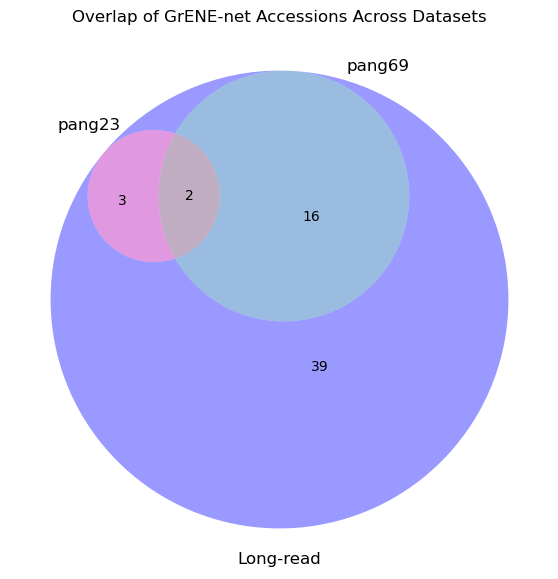

In [106]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3

# Boolean columns
set23 = set(grenenet_accession[grenenet_accession['in_pang23'] == True]['acc_ID'])
set69 = set(grenenet_accession[grenenet_accession['in_pang69'] == True]['acc_ID'])
setLR = set(grenenet_accession[grenenet_accession['in_longreads'] == True]['acc_ID'])

plt.figure(figsize=(7,7))
venn3([set23, set69, setLR],
      set_labels=('pang23', 'pang69', 'Long-read'))
plt.title("Overlap of GrENE-net Accessions Across Datasets")
plt.show()


In [301]:
len(grenenet_accession[(grenenet_accession['in_longreads'] == True)]) 

60

In [306]:
grenenet_accession

,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2,in_pang23,in_pang69,in_longreads
0,MAR2-3,FRA,159,Monsanto,MAR2-3,FRA,Mar2,47,4,Valerie Le Corre,NaN,CS77070,western_europe,NaN,blu_circle,False,False,True
1,PYL-6,FRA,265,Monsanto,PYL-6,FRA,PYL,45,-1,Valerie Le Corre,NaN,CS77198,admixed,NaN,forbidden,False,False,False
2,Kar-1,KGZ,763,Salk,Kar-1,KGZ,Karakol,42,74,Olivier Loudet,2004-07-03 0:00:00,CS76522,asia,NaN,purple_circle,False,True,True
3,Sus-1,KGZ,765,Salk,Sus-1,KGZ,Susamyr,42,73,Olivier Loudet,2004-07-04 0:00:00,CS76607,asia,NaN,purple_circle,False,True,True
4,Dja-1,KGZ,766,Salk,Dja-1,KGZ,Djarly,43,74,Olivier Loudet,2004-07-07 0:00:00,CS76473,asia,NaN,purple_circle,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,Yeg-1,ARM,10011,MPI,Yeg-1,ARM,Yeghegis,40,45,James Beck,1999-12-30 0:00:00,CS76394,asia,NaN,purple_circle,False,False,False
227,Lerik1-3,AZE,10013,MPI,Lerik1-3,AZE,Lerik,39,49,James Beck,NaN,CS76388,italy_balkan_caucasus,NaN,wht_circle,False,False,False
228,Xan-1,AZE,10014,MPI,Xan-1,AZE,Xanbulan,39,49,James Beck,1999-12-30 0:00:00,CS76387,italy_balkan_caucasus,NaN,wht_circle,False,False,False
229,Ziv-24208,ISR,100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False


In [305]:
grenenet_accession[(grenenet_accession['in_longreads'] == True)] #[['name_grene',	'country_grene',	'acc_ID']] #.to_csv('overlap_grenenet_lra.csv',index=False)

,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2,in_pang23,in_pang69,in_longreads
0,MAR2-3,FRA,159,Monsanto,MAR2-3,FRA,Mar2,47,4,Valerie Le Corre,NaN,CS77070,western_europe,NaN,blu_circle,False,False,True
2,Kar-1,KGZ,763,Salk,Kar-1,KGZ,Karakol,42,74,Olivier Loudet,2004-07-03 0:00:00,CS76522,asia,NaN,purple_circle,False,True,True
3,Sus-1,KGZ,765,Salk,Sus-1,KGZ,Susamyr,42,73,Olivier Loudet,2004-07-04 0:00:00,CS76607,asia,NaN,purple_circle,False,True,True
5,Zal-1,KGZ,768,Salk,Zal-1,KGZ,Zalisky,43,76,Olivier Loudet,2004-07-18 0:00:00,CS76634,asia,NaN,purple_circle,False,True,True
6,Neo-6,TJK,772,Salk,Neo-6,TJK,Neo-Shahdara,37,72,Olivier Loudet,2004-07-25 0:00:00,CS76560,asia,NaN,purple_circle,False,False,True
11,Ty-1,UK,5784,Monsanto,Ty-1,UK,Taynuilt,56,-5,D. Ratcliffe,1961-01-01 0:00:00,CS78790,admixed,NaN,forbidden,False,False,True
28,TRA 01,SWE,6244,GMI,TRÃ 01,SWE,TRÃ,56,14,Mattias Jakobsson,2003-01-01 0:00:00,CS77384,north_sweden,NaN,orange_circle,False,False,True
29,An-1,BEL,6898,Salk,An-1,BEL,An,51,4,Albert Kranz,NaN,CS76435,admixed,NaN,forbidden,False,False,True
30,Cvi-0,CPV,6911,Salk,Cvi-0,CPV,Cvi,15,-24,Albert Kranz,NaN,CS76789,relict,Y,grn_circle,False,True,True
31,Ei-2,GER,6915,Salk,Ei-2,GER,Eifel,50,6,Albert Kranz,NaN,CS76478,germany,NaN,ltblu_circle,False,False,True


In [139]:
grenenet_accession[(grenenet_accession['in_longreads'] == False) & (grenenet_accession['in_pang23'] == True)]

,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2,in_pang23,in_pang69,in_longreads


In [140]:
grenenet_accession[(grenenet_accession['in_longreads'] == False) & (grenenet_accession['in_pang69'] == True)]

,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2,in_pang23,in_pang69,in_longreads


In [141]:
grenenet_accession

,name_grene,country_grene,acc_ID,seq_by,name_1001,country_1001,name_2,lat,lon,collector,date,cs_number,admixture_group,unknown,unknown2,in_pang23,in_pang69,in_longreads
0,MAR2-3,FRA,159,Monsanto,MAR2-3,FRA,Mar2,47,4,Valerie Le Corre,NaN,CS77070,western_europe,NaN,blu_circle,False,False,True
1,PYL-6,FRA,265,Monsanto,PYL-6,FRA,PYL,45,-1,Valerie Le Corre,NaN,CS77198,admixed,NaN,forbidden,False,False,False
2,Kar-1,KGZ,763,Salk,Kar-1,KGZ,Karakol,42,74,Olivier Loudet,2004-07-03 0:00:00,CS76522,asia,NaN,purple_circle,False,True,True
3,Sus-1,KGZ,765,Salk,Sus-1,KGZ,Susamyr,42,73,Olivier Loudet,2004-07-04 0:00:00,CS76607,asia,NaN,purple_circle,False,True,True
4,Dja-1,KGZ,766,Salk,Dja-1,KGZ,Djarly,43,74,Olivier Loudet,2004-07-07 0:00:00,CS76473,asia,NaN,purple_circle,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,Yeg-1,ARM,10011,MPI,Yeg-1,ARM,Yeghegis,40,45,James Beck,1999-12-30 0:00:00,CS76394,asia,NaN,purple_circle,False,False,False
227,Lerik1-3,AZE,10013,MPI,Lerik1-3,AZE,Lerik,39,49,James Beck,NaN,CS76388,italy_balkan_caucasus,NaN,wht_circle,False,False,False
228,Xan-1,AZE,10014,MPI,Xan-1,AZE,Xanbulan,39,49,James Beck,1999-12-30 0:00:00,CS76387,italy_balkan_caucasus,NaN,wht_circle,False,False,False
229,Ziv-24208,ISR,100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False


In [145]:
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load Natural Earth low-res world boundaries
world_path = geodatasets.get_path("naturalearth.land")
world = gpd.read_file(world_path)


In [146]:
gdf = gpd.GeoDataFrame(
    grenenet_accession,
    geometry=gpd.points_from_xy(
        grenenet_accession['lon'],
        grenenet_accession['lat']
    ),
    crs="EPSG:4326"
)


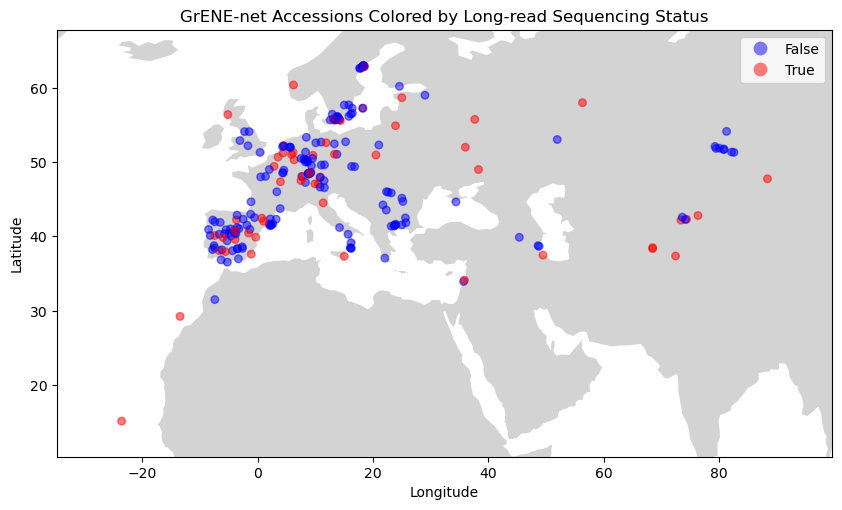

In [156]:
min_lon = grenenet_accession['lon'].min()
max_lon = grenenet_accession['lon'].max()
min_lat = grenenet_accession['lat'].min()
max_lat = grenenet_accession['lat'].max()

# Add 10% padding around each edge
lon_padding = (max_lon - min_lon) * 0.10
lat_padding = (max_lat - min_lat) * 0.10

xmin = min_lon - lon_padding
xmax = max_lon + lon_padding
ymin = min_lat - lat_padding
ymax = max_lat + lat_padding

import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load Natural Earth land polygons
world_path = geodatasets.get_path("naturalearth.land")
world = gpd.read_file(world_path)

# Convert your accessions to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    grenenet_accession,
    geometry=gpd.points_from_xy(
        grenenet_accession['lon'],
        grenenet_accession['lat']
    ),
    crs="EPSG:4326"
)

# Bounding box
min_lon = gdf['lon'].min()
max_lon = gdf['lon'].max()
min_lat = gdf['lat'].min()
max_lat = gdf['lat'].max()

# Padding
lon_padding = (max_lon - min_lon) * 0.10
lat_padding = (max_lat - min_lat) * 0.10

xmin = min_lon - lon_padding
xmax = max_lon + lon_padding
ymin = min_lat - lat_padding
ymax = max_lat + lat_padding

# Plot
fig, ax = plt.subplots(figsize=(10,6))

# Plot land
world.plot(ax=ax, color="lightgrey", edgecolor="white")

# Plot accessions
gdf.plot(
    ax=ax,
    column='in_longreads',
    categorical=True,
    legend=True,
    cmap='bwr',     # or any palette you prefer
    markersize=30,
    alpha = 0.5
)

# Set zoom to bounding box
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GrENE-net Accessions Colored by Long-read Sequencing Status")
plt.show()




In [178]:
full_dt = grenenet_accession.merge(lr_1001, on = 'acc_ID', how = 'outer')

In [179]:
full_dt.columns

Index(['name_grene', 'country_grene', 'acc_ID', 'seq_by', 'name_1001',
       'country_1001', 'name_2', 'lat', 'lon', 'collector', 'date',
       'cs_number', 'admixture_group', 'unknown', 'unknown2', 'in_pang23',
       'in_pang69', 'in_longreads', 'Assembly_ID', 'Accession_Name',
       'Accession_alias', 'Original_Assembly_ID', 'Version', 'CSnumber',
       'Latitude', 'Longitude', 'Altitude', 'Gaps', 'Sum', 'Largest',
       'Pangenome_reference', 'Primary_Sequencing_Technology', 'Assembler',
       'Individual_or_pool', 'Latest_released_Year', 'Published',
       'Publication_First_author', 'Publication_year', 'Publication_Journal',
       'Publication_DOI', 'Publication_URL', 'Best_unique_assembly'],
      dtype='object')

In [180]:
# Prefer GrENE-net coords, fall back to long-read coords
full_dt['LAT'] = full_dt['lat'].fillna(full_dt['Latitude'])
full_dt['LON'] = full_dt['lon'].fillna(full_dt['Longitude'])


In [181]:
def classify(row):
    if row['in_longreads'] and not pd.isna(row['name_grene']):
        return 'both'
    elif row['in_longreads'] and pd.isna(row['name_grene']):
        return 'longread_only'
    elif (not row['in_longreads']) and not pd.isna(row['name_grene']):
        return 'grenenet'
    else:
        return 'other'

full_dt['dataset'] = full_dt.apply(classify, axis=1)


In [182]:
map_df = full_dt.dropna(subset=['LAT', 'LON'])


In [184]:
map_df['LON'].astype(float)

1       4
2      -1
3     -73
6     -73
8      74
       ..
569    -4
570    -5
571    -5
572    -8
573    -8
Name: LON, Length: 414, dtype: float64

In [185]:
import geopandas as gpd
from geodatasets import get_path

gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df['LON'], map_df['LAT']),
    crs="EPSG:4326"
)


In [186]:
import geodatasets
world = gpd.read_file(get_path("naturalearth.land"))


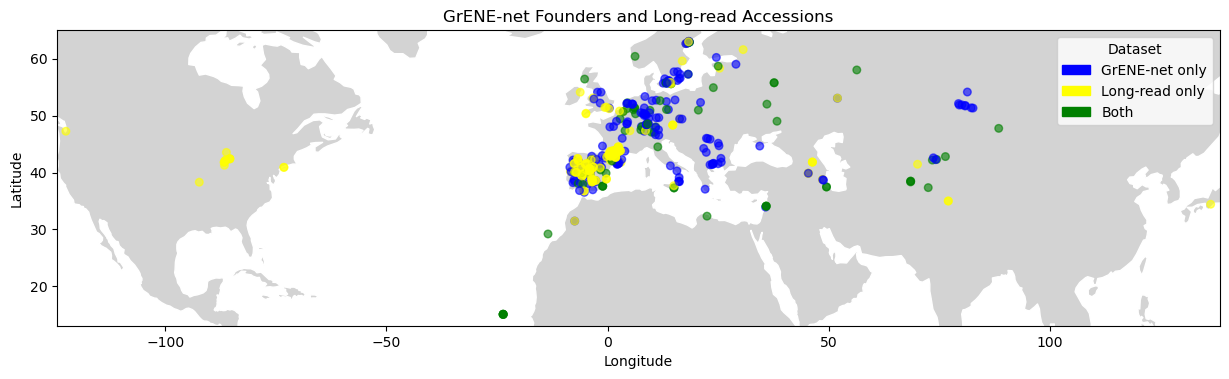

In [194]:
import matplotlib.pyplot as plt

# Define custom colors for dataset categories
color_map = {
    'grenenet': 'blue',
    'longread_only': 'yellow',
    'both': 'green'
}

# Assign colors using the dataset column
gdf['color'] = gdf['dataset'].map(color_map)

fig, ax = plt.subplots(figsize=(15,10))

# Base map
world.plot(ax=ax, color="lightgrey", edgecolor="white")

# Plot the accessions
gdf.plot(
    ax=ax,
    color=gdf['color'],    # use custom colors
    markersize=30,

    alpha=0.6
)

# Add a manual legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='blue', label='GrENE-net only'),
    mpatches.Patch(color='yellow', label='Long-read only'),
    mpatches.Patch(color='green', label='Both')
]
ax.legend(handles=legend_handles, title="Dataset")

# Zoom to bounding box
min_lon, max_lon = gdf['LON'].min(), gdf['LON'].max()
min_lat, max_lat = gdf['LAT'].min(), gdf['LAT'].max()

ax.set_xlim(min_lon - 2, max_lon + 2)
ax.set_ylim(min_lat - 2, max_lat + 2)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GrENE-net Founders and Long-read Accessions")
plt.show()


In [3]:
## full ven diagram
import pandas as pd

In [4]:
pang_69 = pd.read_csv('pang_69/accessions.csv', skiprows=2)
pang_23 = pd.read_csv('23_ara_pang/accessions.csv')

lr_1001 = pd.read_csv('long_read_seq_ara/Athaliana_assembly_IDs_OVERVIEW.csv', dtype=str)

grenenet = pd.read_csv('long_read_seq_ara/grene_ecotypes.csv')[['ID', 'name', 'country']]
grenenet = grenenet.dropna()
grenenet['acc_ID'] = grenenet['ID'].astype(int)


In [5]:
pang_69 = pang_69.rename(columns={'Accession': 'accession_name'})
pang_69['dataset_pang69'] = True


In [6]:

pang_23 = pang_23.rename(columns={'Name': 'accession_name'})
pang_23['dataset_pang23'] = True


In [7]:
grenenet = grenenet.rename(columns={'name': 'accession_name'})
grenenet['dataset_grenenet'] = True

In [8]:
## delete the F1 (Col-0/Cvi-0)
lr_1001 = lr_1001[lr_1001['Accession_Name'] != 'F1 (Col-0/Cvi-0)']

In [9]:
lr_1001 = lr_1001.rename(columns={
    'Accession_ID': 'acc_ID',
    'Accession_Name': 'accession_name'
})
lr_1001['acc_ID'] = lr_1001['acc_ID'].astype(str)
lr_1001['dataset_longread'] = True

lr_1001['acc_ID'] = lr_1001['acc_ID'].astype(int)




In [10]:
lr_1001['acc_ID'].astype(int)

0      6909
1      6909
2      6909
3      7213
5      7213
       ... 
425    4840
426    5279
427    9133
428    9134
429    7417
Name: acc_ID, Length: 429, dtype: int64

In [11]:
gr_lr = grenenet[['accession_name','acc_ID', 'dataset_grenenet' ]].merge(lr_1001[['accession_name','acc_ID', 'dataset_longread']], on = 'acc_ID', how = 'outer', suffixes=('_grene', '_lr'))


In [12]:
gr_lr = gr_lr.drop_duplicates()

In [13]:
gr_lr_pg23 = gr_lr.merge(pang_23[['accession_name', 'dataset_pang23']], left_on = 'accession_name_lr', right_on = 'accession_name', how = 'outer')

In [14]:
gr_lr_pg23_pg69 = gr_lr_pg23.merge(pang_69[['accession_name', 'dataset_pang69']], left_on = 'accession_name_lr', right_on = 'accession_name', how = 'outer')
## tehre are 8 that dont match ? 

In [15]:
len(gr_lr_pg23_pg69)

535

In [16]:
cols = ['dataset_grenenet','dataset_longread','dataset_pang23','dataset_pang69']

for c in cols:
    gr_lr_pg23_pg69[c] = gr_lr_pg23_pg69[c].fillna(False)


In [17]:
# Create sets by row index
setGRE = set(gr_lr_pg23_pg69.index[gr_lr_pg23_pg69['dataset_grenenet'] == True])
setLR  = set(gr_lr_pg23_pg69.index[gr_lr_pg23_pg69['dataset_longread'] == True])
set23  = set(gr_lr_pg23_pg69.index[gr_lr_pg23_pg69['dataset_pang23'] == True])
set69  = set(gr_lr_pg23_pg69.index[gr_lr_pg23_pg69['dataset_pang69'] == True])


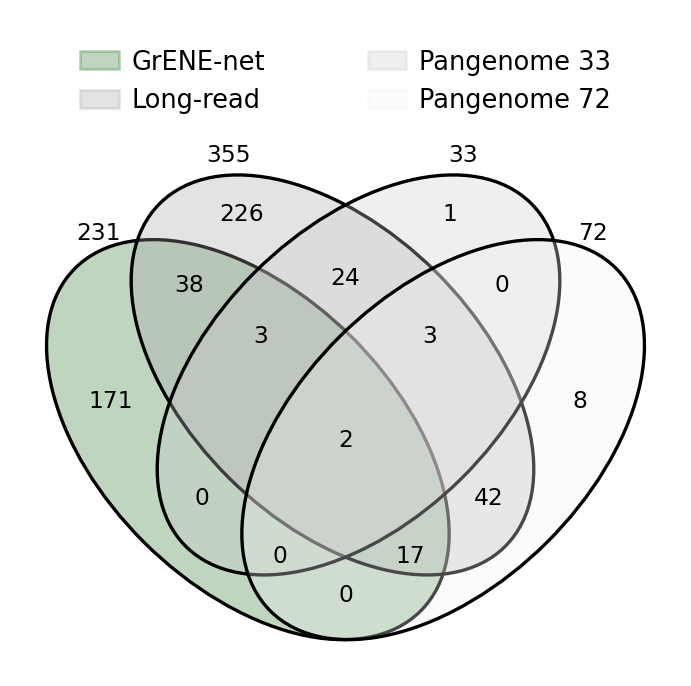

In [24]:
import matplotlib.pyplot as plt
from venny4py.venny4py import venny4py


sets = {
    "GrENE-net": setGRE,
    "Long-read": setLR,
    "Pangenome 33": set23,
    "Pangenome 72": set69
}

palette = ["#2E762E", "#A5A5A5", "#CCCCCC", "#F2F2F2"]  # blue, orange, green, purple

venny4py(
    sets=sets,
    colors=palette,
    edge_color="black",
    line_width=1.2,
    dpi=300,
    size=4.2,
)

plt.savefig("venn_gr_vs_available.png", dpi=300, bbox_inches="tight")
plt.show()



In [282]:
lr_1001['acc_ID'].drop_duplicates()


0      6909
3      7213
6      1741
8      6942
11     6898
       ... 
424    4857
425    4840
426    5279
427    9133
429    7417
Name: acc_ID, Length: 355, dtype: int64